In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
pTrue = 0.001

In [3]:
f = open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230823_IQAE/results_IQAE_pTrue0001_epsilon0001_alphaTot005.dat","rb")
results = pickle.load(f)

In [4]:
results[0]

{'Estimate': 0.0009493662636231631,
 'TotalOracleCalls': 3645,
 'nGrover': [0, 1, 3, 7, 15],
 'nShots': [62, 34, 37, 159, 27],
 'n1s': [0, 0, 2, 44, 18],
 'thetaIntervals': [[0, 1.5707963267948966],
  [0.0, 0.5212457687788165],
  [0.0, 0.2233745560418127],
  [0.0005521239061016787, 0.10448748751590042],
  [0.02423203661893798, 0.05057074189202233],
  [0.015615822093554771, 0.044162360144484145]],
 'ampSqIntervals': [[0, 1],
  [0.0, 0.2479650121560565],
  [0.0, 0.04907181700997086],
  [3.0484077671300394e-07, 0.010877961253954533],
  [0.0005870766763748731, 0.002555220580614762],
  [0.00024383407872722513, 0.001949046474891978]]}

In [5]:
errors = [r["Estimate"] - pTrue for r in results]

In [6]:
np.mean(errors)

1.1808182208720516e-05

In [7]:
nGroverLastVals, countNGroverLast = np.unique([r["nGrover"][-1] for r in results], return_counts=True)
print(nGroverLastVals)
print(countNGroverLast)

[15 27 28 29 30]
[9957    1    5   12   25]


In [8]:
nShotsLast = [r["nShots"][-1] for r in results]
nShotsLastVals, countNShotsLast = np.unique(nShotsLast, return_counts=True)
dfnShotsLast = pd.DataFrame({"nShotsLast": nShotsLastVals, "count": countNShotsLast})
print(dfnShotsLast)

    nShotsLast  count
0            9      1
1           10      6
2           11     14
3           12      9
4           13      1
5           14      7
6           16      3
7           18      2
8           21     44
9           22     24
10          23     45
11          24    270
12          25    808
13          26    708
14          27   3731
15          28   4215
16          29     24
17          30     13
18          31     13
19          32     16
20          33     10
21          34      5
22          35      6
23          36      5
24          37      2
25          38     16
26          40      1
27          41      1


In [9]:
from BiasCorrection import BiasCordeiroKlein, ExpectedLogLikDer2nd, BiasTaylorExpTo2nd, BiasTaylorExpTo3rd

In [10]:
biases = []
errorsBiasCorrected =[]
for i in range(len(results)):
    r = results[i]
    estim = r["Estimate"]
    bias = BiasCordeiroKlein(estim, r["nGrover"][-1], r["nShots"][-1])
    biases.append(bias)
    errorsBiasCorrected.append(estim - bias - pTrue)

In [11]:
# ax = plt.gca()
# plt.plot(np.array().cumsum())
# plt.show()

In [12]:
biases[:100]

[4.514147306091733e-05,
 6.331637860598195e-05,
 8.934119301069239e-05,
 0.00010937618961097086,
 0.00010937618961097086,
 2.9191715212575852e-05,
 7.473992804844447e-05,
 5.389830430396824e-05,
 6.331637860598195e-05,
 2.9191715212575852e-05,
 5.389830430396824e-05,
 6.331637860598195e-05,
 3.190036943542728e-05,
 6.331637860598195e-05,
 5.389830430396824e-05,
 4.514147306091733e-05,
 6.331637860598195e-05,
 4.5929441501212705e-05,
 4.514147306091733e-05,
 8.934119301069239e-05,
 4.514147306091733e-05,
 6.331637860598195e-05,
 7.473992804844447e-05,
 4.514147306091733e-05,
 5.389830430396824e-05,
 5.389830430396824e-05,
 2.1567508426209928e-05,
 3.808833761581178e-05,
 2.9191715212575852e-05,
 6.331637860598195e-05,
 2.338212205065032e-05,
 4.5929441501212705e-05,
 8.934119301069239e-05,
 8.934119301069239e-05,
 7.473992804844447e-05,
 6.331637860598195e-05,
 2.9191715212575852e-05,
 4.514147306091733e-05,
 3.190036943542728e-05,
 6.331637860598195e-05,
 4.5929441501212705e-05,
 3.808

In [13]:
errors = [r["Estimate"] - pTrue for r in results]

In [14]:
errors[:100]

[-5.063373637683691e-05,
 0.00014069265996463826,
 0.00031860075224895957,
 0.00041828315753802015,
 0.00041828315753802015,
 -0.00025622698902517276,
 0.00023472135784636822,
 5.452437647239278e-05,
 0.00014069265996463826,
 -0.00025622698902517276,
 5.452437647239278e-05,
 0.00014069265996463826,
 -0.00019708074939905776,
 0.00014069265996463826,
 5.452437647239278e-05,
 -5.063373637683691e-05,
 0.00014069265996463826,
 -2.5262306782149993e-05,
 -5.063373637683691e-05,
 0.00031860075224895957,
 -5.063373637683691e-05,
 0.00014069265996463826,
 0.00023472135784636822,
 -5.063373637683691e-05,
 5.452437647239278e-05,
 5.452437647239278e-05,
 -0.0003582535855264034,
 -0.0001261449433714488,
 -0.00025622698902517276,
 0.00014069265996463826,
 -0.0003251520706678897,
 -2.5262306782149993e-05,
 0.00031860075224895957,
 0.00031860075224895957,
 0.00023472135784636822,
 0.00014069265996463826,
 -0.00025622698902517276,
 -5.063373637683691e-05,
 -0.00019708074939905776,
 0.0001406926599646382

In [15]:
np.mean(errors)

1.1808182208720516e-05

In [16]:
np.std(errors)

0.00020614944641022604

In [17]:
print(np.sum(errors))
print(np.std(errors) * np.sqrt(len(errors)))

0.11808182208720516
0.020614944641022603


In [18]:
thetaTrue = np.arcsin(np.sqrt(pTrue))
print(thetaTrue)

0.03162804943757168


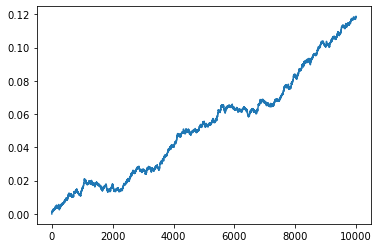

In [19]:
ax = plt.gca()
plt.plot(np.array(errors).cumsum())
plt.show()

In [20]:
nGroverLastVals, countNGroverLast = np.unique([r["nGrover"][-1] for r in results], return_counts=True)
print(nGroverLastVals)
print(countNGroverLast)

[15 27 28 29 30]
[9957    1    5   12   25]


In [21]:
nShotLastVals, countNShotLast = np.unique([r["nShots"][-1] for r in results], return_counts=True)
pd.DataFrame({"nShotLastVals": nShotLastVals, "count": countNShotLast})

,nShotLastVals,count
0,9,1
1,10,6
2,11,14
3,12,9
4,13,1
5,14,7
6,16,3
7,18,2
8,21,44
9,22,24


In [22]:
BiasTaylorExpTo2nd(pTrue, 15, 27)

1.7380074732008416e-05

In [23]:
BiasTaylorExpTo3rd(pTrue, 15, 27)

1.628815046755585e-05

In [29]:
errorsGrover15vsShot =[]
nShot = []
cnt = []
for nShotsLast in nShotLastVals:
    temp = []
    for r in results:
        if (r["nGrover"][-1] == 15) and (r["nShots"][-1] == nShotsLast):
            temp.append(r["Estimate"] - pTrue)

    if len(temp) > 0:
        nShot.append(nShotsLast)
        cnt.append(len(temp))
        errorsGrover15vsShot.append(np.mean(temp))

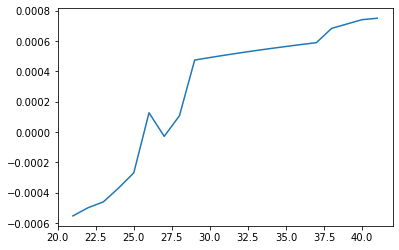

In [30]:
ax = plt.gca()
plt.plot(nShot, errorsGrover15vsShot)
plt.show()

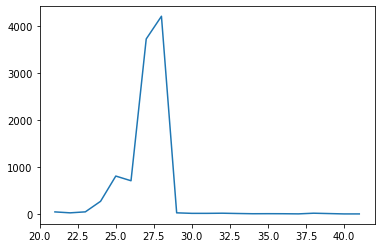

In [41]:
ax = plt.gca()
plt.plot(nShot, cnt)
plt.show()

In [32]:
np.dot(cnt, errorsGrover15vsShot) / np.sum(cnt)

1.187041948530298e-05

In [43]:
cnt = np.array(cnt)
errorsGrover15vsShot = np.array(errorsGrover15vsShot)
idMaj = np.where(cnt > 1000)
np.dot(cnt[idMaj], errorsGrover15vsShot[idMaj]) / np.sum(cnt[idMaj])

4.3126744991230476e-05

In [27]:
print(BiasTaylorExpTo3rd(pTrue, 15, 26))
print(BiasTaylorExpTo3rd(pTrue, 15, 27))
print(BiasTaylorExpTo3rd(pTrue, 15, 28))

1.6871005433556194e-05
1.628815046755585e-05
1.5744035342617908e-05


In [45]:
print(BiasCordeiroKlein(pTrue, 15, 24))
print(BiasCordeiroKlein(pTrue, 15, 25))
print(BiasCordeiroKlein(pTrue, 15, 26))
print(BiasCordeiroKlein(pTrue, 15, 27))
print(BiasCordeiroKlein(pTrue, 15, 28))

5.644481426837017e-05
5.418702169763536e-05
5.210290547849554e-05
5.0173168238551266e-05
4.8381269372888724e-05


In [28]:
errorsGroverNot15 =[]
for r in results:
    if r["nGrover"][-1] != 15:
        errorsGroverNot15.append(r["Estimate"] - pTrue)

np.mean(errorsGroverNot15)

-2.603365766434042e-06